In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("hospital_readmissions.csv")

In [3]:
data.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [4]:
data.shape

(25000, 17)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [6]:
data.isnull().sum()

age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

In [7]:
data.drop_duplicates(inplace=True)

# EDA

### Which age group gets readmitted most?

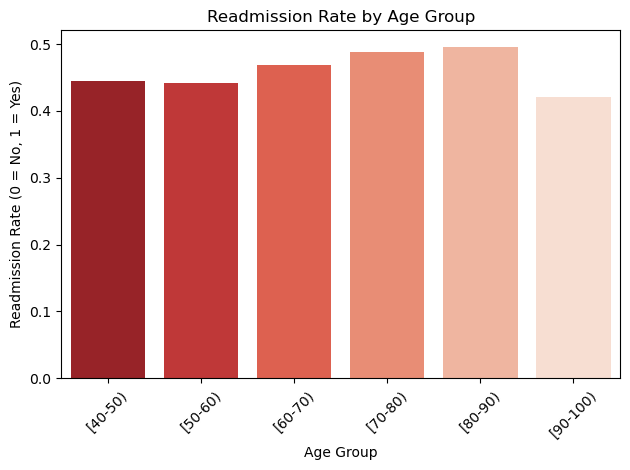

In [8]:
data['readmitted'] = data['readmitted'].map({'yes':1, 'no':0})

readmitted_age = data.groupby('age')['readmitted'].mean().reset_index()
readmitted_age.columns=['age','readmission_rate']

sns.barplot(data=readmitted_age, x='age', y='readmission_rate', palette='Reds_r',hue='age',legend=False)
plt.title('Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (0 = No, 1 = Yes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Does longer hospital stay reduce readmission?

C:\Users\OM KAPILESHWARI\AppData\Local\Temp\ipykernel_20296\2139639356.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,x='readmitted',y='time_in_hospital',palette='Set2')


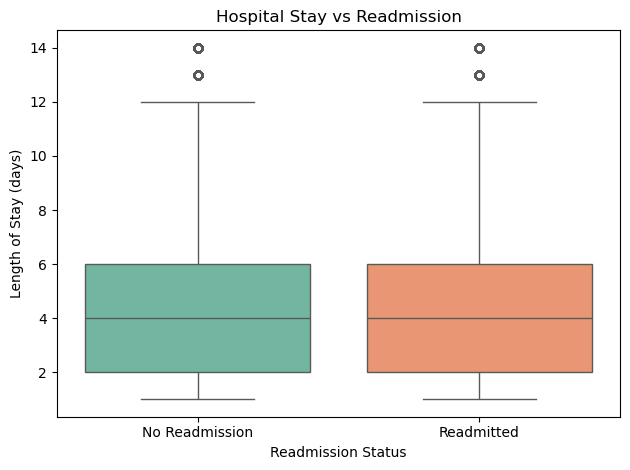

In [9]:
sns.boxplot(data=data,x='readmitted',y='time_in_hospital',palette='Set2')
plt.xticks([0,1], ['No Readmission','Readmitted'])  # replace 0/1 with labels
plt.xlabel('Readmission Status')
plt.ylabel('Length of Stay (days)')
plt.title('Hospital Stay vs Readmission')
plt.tight_layout()
plt.show()


### Which diagnosis has highest readmission rate?

         diagnosis  readmission_rate
7      Respiratory          0.492028
0      Circulatory          0.481898
1         Diabetes          0.467467
2        Digestive          0.466098
6            Other          0.463607
3           Injury          0.427784
5  Musculoskeletal          0.420534
4          Missing          0.309917


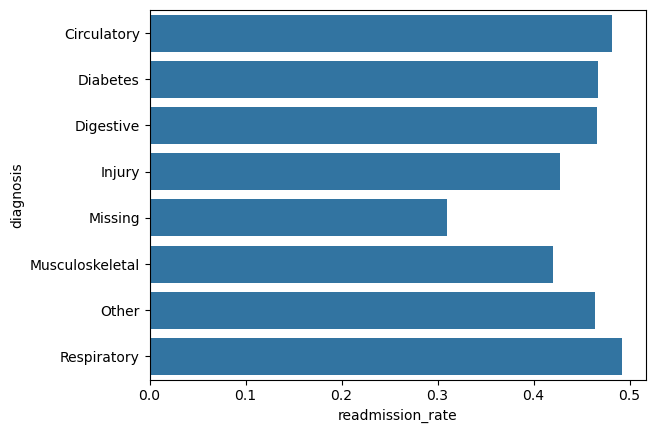

In [10]:
diag = ['diag_1','diag_2','diag_3']

diag_long = data.melt(
    id_vars=['readmitted'],
    value_vars=diag,
    var_name='daig_type',
    value_name='diagnosis'
)

diag_readmit = diag_long.groupby('diagnosis')['readmitted'].mean().reset_index()
diag_readmit.columns = ['diagnosis', 'readmission_rate']

# Sort to find top diagnoses
top_diag = diag_readmit.sort_values('readmission_rate', ascending=False).head(10)
print(top_diag)

sns.barplot(data=diag_readmit,x='readmission_rate',y='diagnosis')
plt.xlabel("readmission_rate")
plt.ylabel("diagnosis")
plt.show()

### Do more medications = more readmissions?

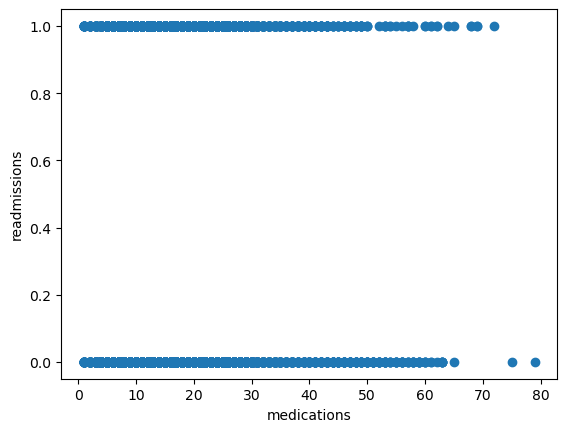

In [11]:
plt.scatter(data['n_medications'],data['readmitted'],marker='o')
plt.xlabel("medications")
plt.ylabel("readmissions")
plt.show()

  diabetes_med  readmission_rate
0           no          0.413548
1          yes          0.487154


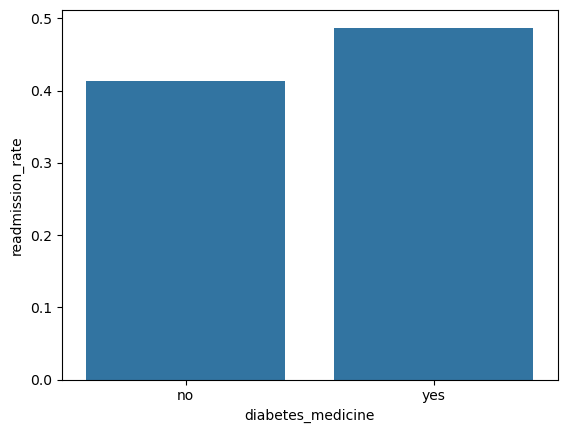

In [12]:
med_readmit = data.groupby('diabetes_med')['readmitted'].mean().reset_index()
med_readmit.columns = ['diabetes_med','readmission_rate']

print(med_readmit.head())
sns.barplot(data=med_readmit,x='diabetes_med',y='readmission_rate')
plt.xlabel("diabetes_medicine")
plt.ylabel("readmission_rate")
plt.show()

### What % of patients were readmitted?

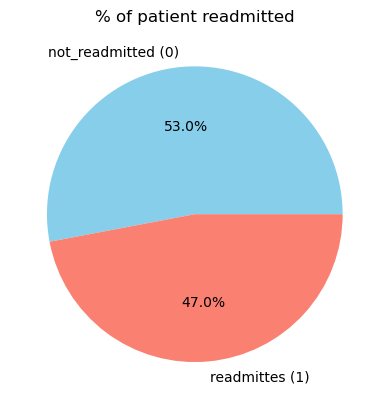

In [13]:
counts = data['readmitted'].value_counts()
counts.sort_index()
labels = ["not_readmitted (0)","readmittes (1)"]

plt.pie(counts,labels=labels,autopct='%1.1f%%',colors=["skyblue","salmon"])
plt.title("% of patient readmitted")
plt.show()
          

C:\Users\OM KAPILESHWARI\AppData\Local\Temp\ipykernel_20296\898752206.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts_df, x='readmitted', y='count', palette='Set2')


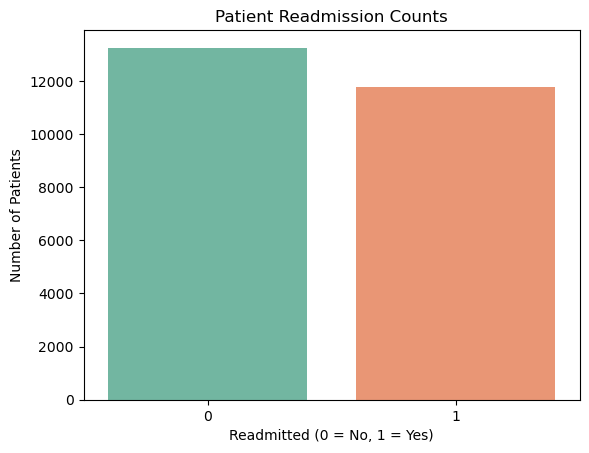

In [14]:
counts = data['readmitted'].value_counts().sort_index()

# Convert to DataFrame
counts_df = counts.reset_index()
counts_df.columns = ['readmitted','count']

# Plot bar chart
sns.barplot(data=counts_df, x='readmitted', y='count', palette='Set2')

plt.xlabel("Readmitted (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.title("Patient Readmission Counts")
plt.show()

In [15]:
data.to_csv("healthcare_cleaned.csv",index=False)